# Bài thực hành chương 2

Notebook này giải các yêu cầu chương 2: toán tử điểm ảnh, lọc tuyến tính, phát hiện cạnh, kernel tùy chỉnh, so sánh bộ lọc và lọc phi tuyến.

**Cách dùng nhanh:** có thể chạy từng cell bài tập độc lập. Có thể đổi `IMAGE_PATH` sang ảnh riêng của bạn.

## Chuẩn bị thư viện và ảnh đầu vào

**Input:** một ảnh bất kỳ.

**Output:** ảnh gốc, ảnh xám và thư mục lưu kết quả.

**Thuật toán:** đọc ảnh có sẵn bằng OpenCV, sau đó áp dụng các phép xử lý trong từng câu bài tập.

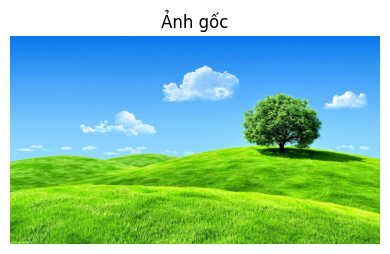

In [1]:
# !pip install opencv-python matplotlib numpy
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

IMAGE_PATH = 'image/anh_chuong_2.jpg'
OUTPUT_DIR = Path('outputs_chapter_2')
OUTPUT_DIR.mkdir(exist_ok=True)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

def show_images(items, cols=None):
    cols = cols or len(items)
    rows = (len(items) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), squeeze=False)
    for ax, (title, img) in zip(axes.ravel(), items):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(title)
        ax.axis('off')
    for ax in axes.ravel()[len(items):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_images([('Ảnh gốc', image_rgb)])


# I. Toán tử điểm ảnh

Toán tử điểm ảnh xử lý từng pixel độc lập, không cần xét vùng lân cận.

## Câu I.1. Thay đổi độ sáng

**Input:** ảnh gốc và giá trị cộng/trừ `beta`.

**Output:** ảnh sáng hơn và tối hơn.

**Thuật toán:** cộng hoặc trừ cùng một hằng số vào mọi pixel, sau đó chặn giá trị trong đoạn `[0, 255]`.

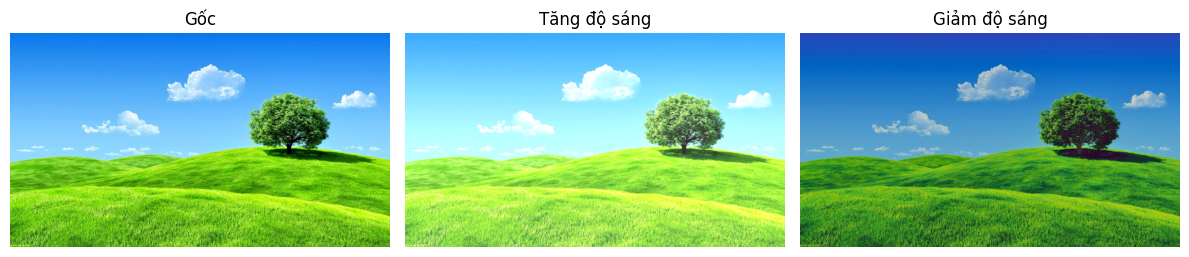

In [2]:
brighter = cv2.convertScaleAbs(image_bgr, alpha=1, beta=50)
darker = cv2.convertScaleAbs(image_bgr, alpha=1, beta=-50)

cv2.imwrite(str(OUTPUT_DIR / 'I_1_tang_do_sang.png'), brighter)
cv2.imwrite(str(OUTPUT_DIR / 'I_1_giam_do_sang.png'), darker)
show_images([
    ('Gốc', image_rgb),
    ('Tăng độ sáng', cv2.cvtColor(brighter, cv2.COLOR_BGR2RGB)),
    ('Giảm độ sáng', cv2.cvtColor(darker, cv2.COLOR_BGR2RGB)),
])


## Câu I.2. Thay đổi độ tương phản

**Input:** ảnh gốc và hệ số nhân `alpha`.

**Output:** ảnh tăng tương phản và giảm tương phản.

**Thuật toán:** nhân mỗi pixel với hệ số `alpha`. Nếu `alpha > 1`, tương phản tăng; nếu `0 < alpha < 1`, tương phản giảm.

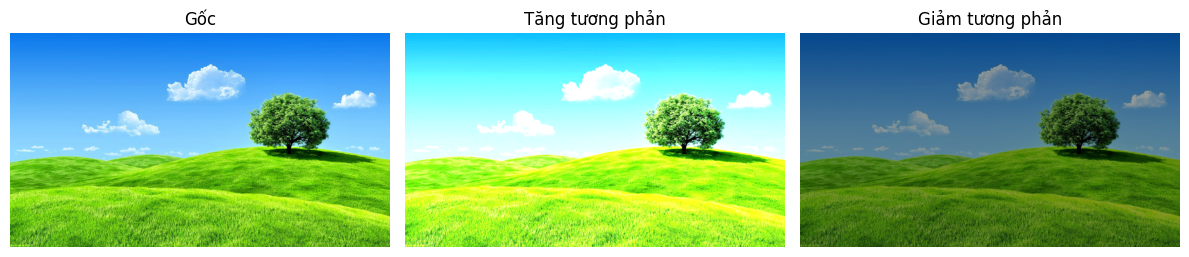

In [3]:
high_contrast = cv2.convertScaleAbs(image_bgr, alpha=1.6)
low_contrast = cv2.convertScaleAbs(image_bgr, alpha=0.6)

cv2.imwrite(str(OUTPUT_DIR / 'I_2_tang_tuong_phan.png'), high_contrast)
cv2.imwrite(str(OUTPUT_DIR / 'I_2_giam_tuong_phan.png'), low_contrast)
show_images([
    ('Gốc', image_rgb),
    ('Tăng tương phản', cv2.cvtColor(high_contrast, cv2.COLOR_BGR2RGB)),
    ('Giảm tương phản', cv2.cvtColor(low_contrast, cv2.COLOR_BGR2RGB)),
])


## Câu I.3. Biến đổi âm bản

**Input:** ảnh gốc.

**Output:** ảnh âm bản.

**Thuật toán:** với ảnh 8-bit, giá trị âm bản được tính bằng `255 - pixel`.

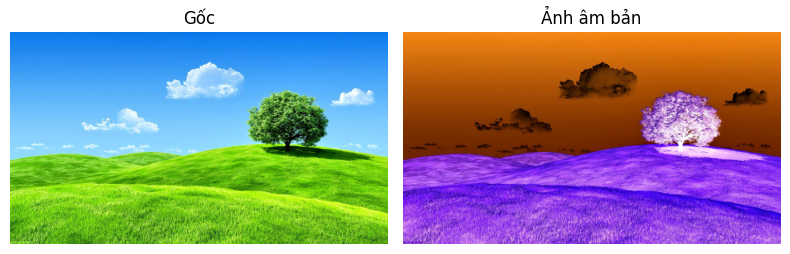

In [4]:
# Tự động lấy 255 trừ từng pixel, giá trị sẽ nằm trong [0, 255]
negative = 255 - image_bgr
cv2.imwrite(str(OUTPUT_DIR / 'I_3_am_ban.png'), negative)
show_images([
    ('Gốc', image_rgb),
    ('Ảnh âm bản', cv2.cvtColor(negative, cv2.COLOR_BGR2RGB)),
])


## Câu I.4. Cắt ngưỡng

**Input:** ảnh xám và giá trị ngưỡng.

**Output:** ảnh nhị phân.

**Thuật toán:** nếu pixel lớn hơn hoặc bằng ngưỡng thì gán 255, ngược lại gán 0.

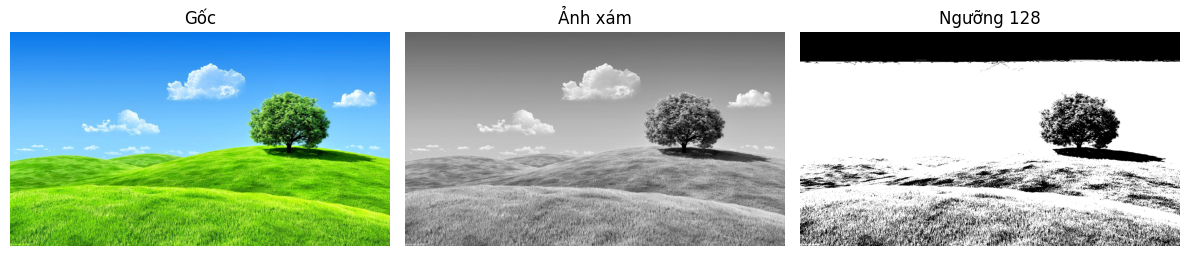

In [5]:
_, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)
cv2.imwrite(str(OUTPUT_DIR / 'I_4_cat_nguong.png'), binary)
show_images([
    ('Gốc', image_rgb),
    ('Ảnh xám', gray),
    ('Ngưỡng 128', binary),
])


# II. Lọc tuyến tính

Lọc tuyến tính tính giá trị pixel mới bằng tổng có trọng số của các pixel trong vùng lân cận.

## Câu II.1. Lọc trung bình

**Input:** ảnh gốc và kích thước kernel.

**Output:** ảnh mờ.

**Thuật toán:** thay mỗi pixel bằng giá trị trung bình của vùng lân cận.

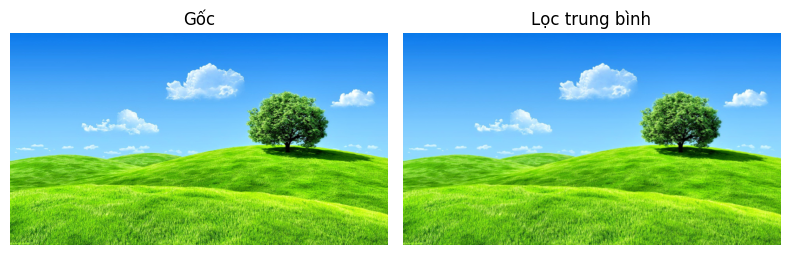

In [6]:
mean_blur = cv2.blur(image_bgr, (3, 3))
cv2.imwrite(str(OUTPUT_DIR / 'II_1_loc_trung_binh.png'), mean_blur)
show_images([
    ('Gốc', image_rgb),
    ('Lọc trung bình', cv2.cvtColor(mean_blur, cv2.COLOR_BGR2RGB)),
])


## Câu II.2. Lọc Gaussian

**Input:** ảnh gốc, kích thước kernel và độ lệch chuẩn.

**Output:** ảnh mờ tự nhiên hơn lọc trung bình.

**Thuật toán:** nhân vùng lân cận với kernel Gaussian, pixel gần tâm có trọng số lớn hơn.

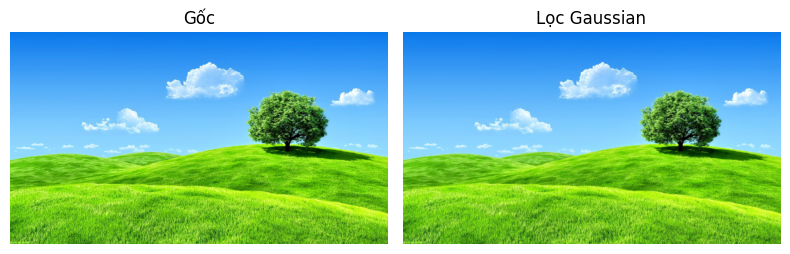

In [7]:
gaussian_blur = cv2.GaussianBlur(image_bgr, (3, 3), 2)
cv2.imwrite(str(OUTPUT_DIR / 'II_2_loc_gaussian.png'), gaussian_blur)
show_images([
    ('Gốc', image_rgb),
    ('Lọc Gaussian', cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB)),
])


## Câu II.3. Làm sắc nét

**Input:** ảnh gốc và kernel làm sắc nét.

**Output:** ảnh có cạnh rõ hơn.

**Thuật toán:** dùng kernel có trọng số tâm lớn, trọng số xung quanh âm để tăng khác biệt giữa pixel trung tâm và vùng lân cận.

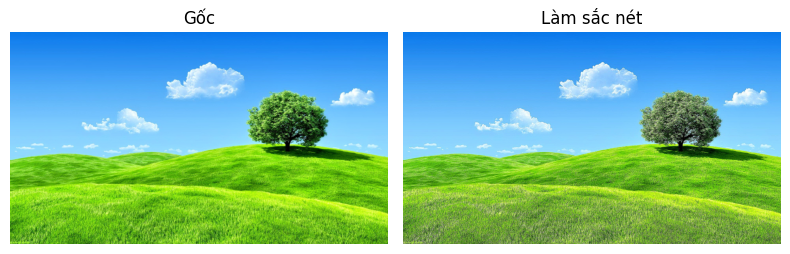

In [8]:
sharpen_kernel = np.array([
    [0, -1, 0], 
    [-1, 5, -1], 
    [0, -1, 0]])
sharpened = cv2.filter2D(image_bgr, -1, sharpen_kernel)

cv2.imwrite(str(OUTPUT_DIR / 'II_3_lam_sac_net.png'), sharpened)
show_images([
    ('Gốc', image_rgb),
    ('Làm sắc nét', cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)),
])


# III. Bài tập nâng cao

## Câu III.1. Phát hiện cạnh Sobel và Prewitt

**Input:** ảnh xám.

**Output:** ảnh biên Sobel và Prewitt.

**Thuật toán:** tính đạo hàm theo hướng x và y, sau đó cộng độ lớn gradient để lấy biên.

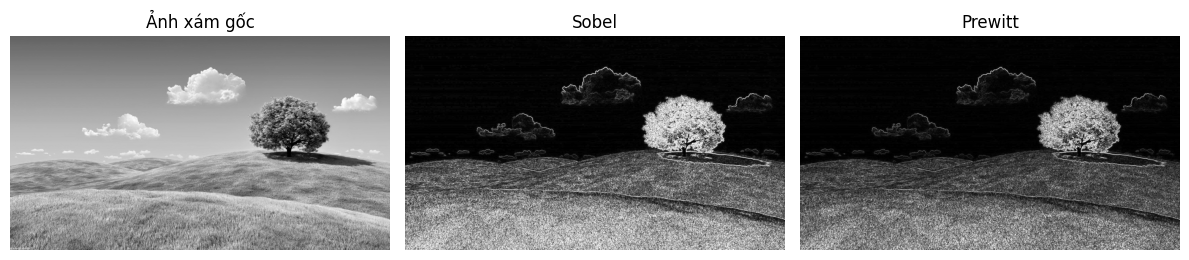

In [9]:
sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.convertScaleAbs(cv2.magnitude(sx, sy))

kx = np.array([
    [-1, 0, 1], 
    [-1, 0, 1], 
    [-1, 0, 1]], np.float32)
ky = np.array([
    [1, 1, 1], 
    [0, 0, 0], 
    [-1, -1, -1]], np.float32)
px = cv2.filter2D(gray, cv2.CV_32F, kx)
py = cv2.filter2D(gray, cv2.CV_32F, ky)
prewitt = cv2.convertScaleAbs(cv2.magnitude(px, py))

cv2.imwrite(str(OUTPUT_DIR / 'III_1_sobel.png'), sobel)
cv2.imwrite(str(OUTPUT_DIR / 'III_1_prewitt.png'), prewitt)
show_images([
    ('Ảnh xám gốc', gray),
    ('Sobel', sobel),
    ('Prewitt', prewitt),
])


## Câu III.2. Tự thiết kế kernel

**Input:** ảnh gốc và các kernel tùy chỉnh.

**Output:** ảnh emboss và ảnh phát hiện cạnh bằng Laplacian tùy chỉnh.

**Thuật toán:** định nghĩa ma trận kernel, sau đó tích chập với ảnh bằng `cv2.filter2D`.

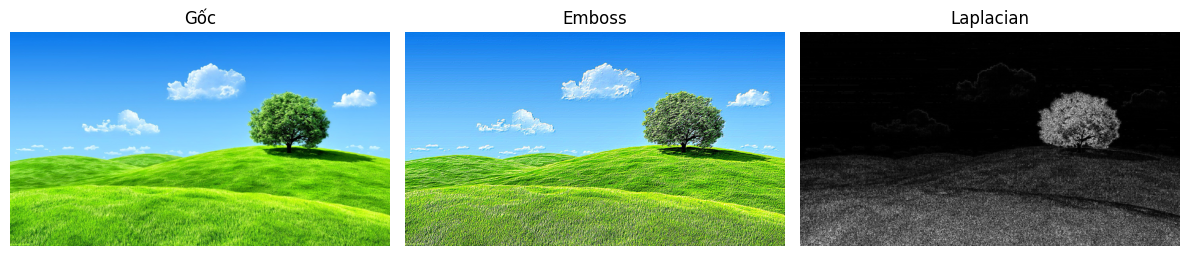

In [10]:
emboss_kernel = np.array([
    [-2, -1, 0], 
    [-1, 1, 1], 
    [0, 1, 2]])
laplacian_kernel = np.array([
    [0, -1, 0], 
    [-1, 4, -1], 
    [0, -1, 0]])

emboss = cv2.filter2D(image_bgr, -1, emboss_kernel)
custom_edge = cv2.convertScaleAbs(cv2.filter2D(gray, cv2.CV_32F, laplacian_kernel))

cv2.imwrite(str(OUTPUT_DIR / 'III_2_kernel_emboss.png'), emboss)
cv2.imwrite(str(OUTPUT_DIR / 'III_2_kernel_laplacian.png'), custom_edge)
show_images([
    ('Gốc', image_rgb),
    ('Emboss', cv2.cvtColor(emboss, cv2.COLOR_BGR2RGB)),
    ('Laplacian', custom_edge),
])


## Câu III.3. So sánh các loại lọc

**Input:** cùng một ảnh gốc.

**Output:** bảng ảnh so sánh kết quả lọc trung bình, Gaussian, median, bilateral và làm sắc nét.

**Thuật toán:** áp dụng nhiều bộ lọc trên cùng ảnh, hiển thị cạnh nhau để đánh giá mức mờ, giữ biên và giảm nhiễu.

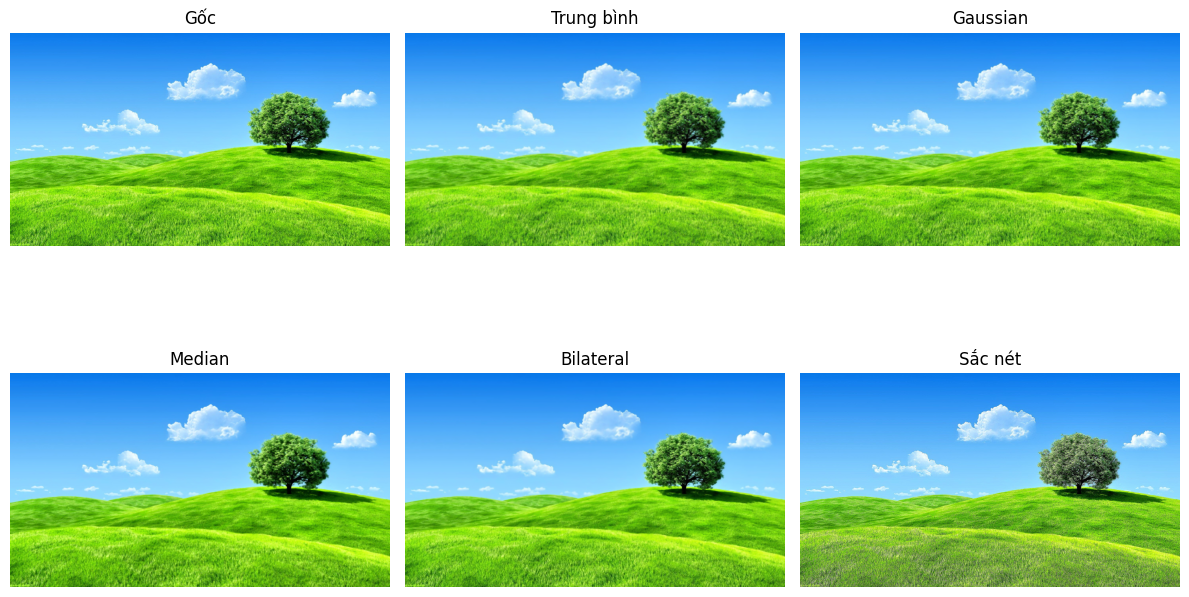

In [11]:
mean_blur = cv2.blur(image_bgr, (5, 5))
gaussian_blur = cv2.GaussianBlur(image_bgr, (5, 5), 1.2)
median_filter = cv2.medianBlur(image_bgr, 5)
bilateral_filter = cv2.bilateralFilter(image_bgr, 9, 75, 75)
sharpened = cv2.filter2D(image_bgr, -1, sharpen_kernel)

filters = [
    ('Gốc', image_bgr), ('Trung bình', mean_blur), ('Gaussian', gaussian_blur),
    ('Median', median_filter), ('Bilateral', bilateral_filter), ('Sắc nét', sharpened),
]
show_images([(name, cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) for name, img in filters], cols=3)


## Câu III.4. Áp dụng lọc phi tuyến

**Input:** ảnh có thể có nhiễu.

**Output:** ảnh sau lọc median và bilateral.

**Thuật toán:**
1. Median filter thay pixel bằng trung vị trong vùng lân cận, hiệu quả với nhiễu muối tiêu.
2. Bilateral filter làm mượt nhưng vẫn giữ biên nhờ xét cả khoảng cách không gian và chênh lệch màu.

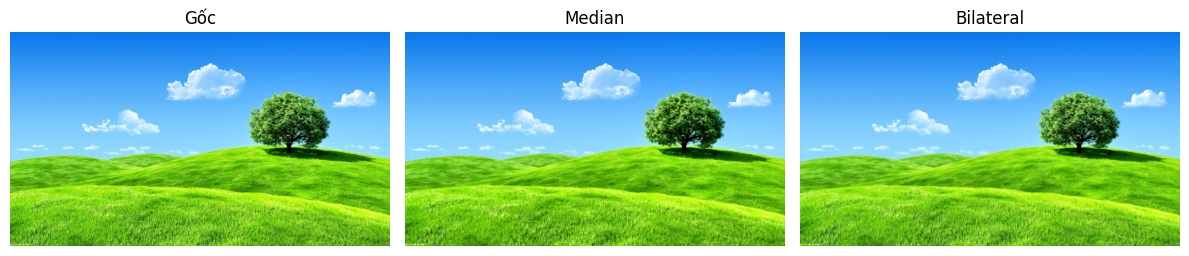

In [12]:
median_filter = cv2.medianBlur(image_bgr, 5)
bilateral_filter = cv2.bilateralFilter(image_bgr, 9, 75, 75)

cv2.imwrite(str(OUTPUT_DIR / 'III_4_median_filter.png'), median_filter)
cv2.imwrite(str(OUTPUT_DIR / 'III_4_bilateral_filter.png'), bilateral_filter)
show_images([
    ('Gốc', image_rgb),
    ('Median', cv2.cvtColor(median_filter, cv2.COLOR_BGR2RGB)),
    ('Bilateral', cv2.cvtColor(bilateral_filter, cv2.COLOR_BGR2RGB)),
])
